<a href="https://colab.research.google.com/github/HarshikaV/WiDS-Global-Datathon-BTT_Riparian/blob/main/BTT_Riparian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Download data from kaggle
2. Navigate the files section on Google Colab
3. Create a folder called 'data'
4. Upload the downloaded daatsets into that folder
5. Run the program.

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/data/train.csv
/content/data/test.csv
/content/data/metaData.csv
/content/data/sample_submission.csv


Quick checks to inspect is data is complete and ready to use:

In [ ]:
df = pd.read_csv('/content/data/train.csv')
df.head(10)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0
5,12773599,1,0.000000,1,184.767610,0.000000,0.000000,0.000000,5.224496,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0,5,7,44.026384,0
6,13122360,1,0.000000,1,119.364203,0.000000,0.000000,0.000000,4.790522,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,21,1,3,14.845392,1
7,13745272,1,0.000000,1,1388.283778,0.000000,0.000000,0.000000,7.236544,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,16,0,6,66.767927,0
8,15247236,2,1.892776,0,4.493970,0.000000,0.000000,0.000000,1.703651,0.000000,...,0.000000,0.106322,0.106322,0.000000,0.000000,18,5,8,39.912630,0
9,15743535,1,0.000000,1,5.218524,0.000000,0.000000,0.000000,1.827533,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,17,2,7,54.638109,1


In [ ]:
# display quick summary of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

In [ ]:
# display statistics for numeric columns
df.describe()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,...,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,5.384397e+07,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,...,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.507456e+07,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,...,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.089246e+07,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,...,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,3.209326e+07,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,5.244094e+07,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,7.457274e+07,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,...,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,9.933973e+07,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,...,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


In [ ]:
# verify columns do not have missing values
df.isnull().sum()

,0
event_id,0
num_perimeters_0_5h,0
dt_first_last_0_5h,0
low_temporal_resolution_0_5h,0
area_first_ha,0
area_growth_abs_0_5h,0
area_growth_rel_0_5h,0
area_growth_rate_ha_per_h,0
log1p_area_first,0
log1p_growth,0


event = 1 --> fire hit within 72h  
event = 0 --> fire never hit within 72h   
Verify this matches the data and analyze the output:

In [ ]:
df["event"].value_counts()

,count
event,
0,152
1,69


Above shows 69 fires hit within 72h and 152 fires did not hit within 72h.  
~31% positive  
~69% censored

In [ ]:
# split dataset into 2 groups (event = 0, event = 1)
# for each group calculate summary stats for time_to_hit_hours column
df.groupby("event")["time_to_hit_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
event,,,,,,,,
0,152.0,50.095555,19.402121,0.374486,38.175209,61.168905,65.113659,66.994474
1,69.0,9.969870,14.528462,0.001220,0.888895,3.534846,14.323375,66.920463


event = 1  
- count = 69 fires
- mean = 10 hrs
- median = 3.5 hrs

This shows most fires that hit within 72 hrs hit pretty early on in the timeline.

event = 0
- count = 152 fires
- mean = 50 hrs
- median 61 hrs

These fires never hit but they were observed for a long time but did not hit in that window of observation (72 hrs).   

Create 4 target columns representing whether each fire hits an evacuation zone within 12, 24, 48, and 72 hrs: `hit_12h`, `hit_24h`, `hit_48h`, `hit_72h`.

In [ ]:
# copy dataframe so the original one does not get modified
df_encoded = df.copy()

# create 4 target columns
df_encoded["hit_12h"] = ((df_encoded["event"] == 1) & (df_encoded["time_to_hit_hours"] <= 12)).astype(int)
df_encoded["hit_24h"] = ((df_encoded["event"] == 1) & (df_encoded["time_to_hit_hours"] <= 24)).astype(int)
df_encoded["hit_48h"] = ((df_encoded["event"] == 1) & (df_encoded["time_to_hit_hours"] <= 48)).astype(int)
df_encoded["hit_72h"] = df_encoded["event"]

In [ ]:
df_encoded.head(10)

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event,hit_12h,hit_24h,hit_48h,hit_72h
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,-0.106026,19,4,5,18.892512,0,0,0,0,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,-0.000000,4,4,6,22.048108,1,0,1,1,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,22,4,8,0.888895,1,1,1,1,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,20,5,8,60.953021,0,0,0,0,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,21,5,7,44.990274,0,0,0,0,0
5,12773599,1,0.000000,1,184.767610,0.000000,0.000000,0.000000,5.224496,0.000000,...,0.000000,0,5,7,44.026384,0,0,0,0,0
6,13122360,1,0.000000,1,119.364203,0.000000,0.000000,0.000000,4.790522,0.000000,...,0.000000,21,1,3,14.845392,1,0,1,1,1
7,13745272,1,0.000000,1,1388.283778,0.000000,0.000000,0.000000,7.236544,0.000000,...,0.000000,16,0,6,66.767927,0,0,0,0,0
8,15247236,2,1.892776,0,4.493970,0.000000,0.000000,0.000000,1.703651,0.000000,...,0.000000,18,5,8,39.912630,0,0,0,0,0
9,15743535,1,0.000000,1,5.218524,0.000000,0.000000,0.000000,1.827533,0.000000,...,0.000000,17,2,7,54.638109,1,0,0,0,1


In [ ]:
# select multiple columns from df and make a new dataframe
df_subset = df_encoded[["hit_12h", "hit_24h", "hit_48h", "hit_72h"]]

# sum each column to find the total number of fires that hit in each timeframe
col_sums = df_subset.sum()

print(col_sums)

hit_12h    49
hit_24h    63
hit_48h    66
hit_72h    69
dtype: int64


Analyzing the results above:  
12h: 22%  
24h: 29%  
48h: 30%  
72h: 31%  

0-12h: 49 fires  
12-24h: 14 fires  
24-48h: 3 fires  
48-72h: 3 fires   

- 221 total fires in the train.csv dataset
    - 69 fires hit within 72 hours
    - The remaining 152 fires did not hit within 72 hours (152 fires)
    - Most hits occur early (within 24 hours), with very few hits after 24 hours

In [ ]:
print(df_encoded.columns.tolist())

['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'time_to_hit_hours', 'event', 'hit_12h', 'hit_24h', 'hit_48h', 'hit_72h']


Columns to drop:  

- Group 1: Identifier & Targets
    - `event_id`: just an ID, no predictive info
    - `time_to_hit_hours`: target variable
    - `event`: target variable
- Group 2: Temporal Coverage
    - None
- Group 3: Growth Features
    - `area_first_ha`: already transformed to log1p_area_first
    - `area_growth_abs_0_5h`: already transformed to log1p_growth
    - `relative_growth_0_5h`: duplicate of area_growth_rel_0_5h
- Group 4:
    - `spread_bearing_deg`: already transformed into spread_bearing_sin and spread_bearing_cos
- Group 5:
    - `closing_speed_abs_m_per_h`: can use abs(closing_speed_m_per_h) instead
- Group 6:
    - None

In [ ]:
# copy target variables for later reference if needed
df_meta = df[["event_id", "time_to_hit_hours", "event"]].copy()
df_meta.head(10)

,event_id,time_to_hit_hours,event
0,10892457,18.892512,0
1,11757157,22.048108,1
2,11945086,0.888895,1
3,12044083,60.953021,0
4,12052347,44.990274,0
5,12773599,44.026384,0
6,13122360,14.845392,1
7,13745272,66.767927,0
8,15247236,39.912630,0
9,15743535,54.638109,1


In [ ]:
# drop columns
df_encoded = df_encoded.drop(["event_id", "time_to_hit_hours", "event", "area_first_ha", "area_growth_abs_0_5h", "relative_growth_0_5h", "spread_bearing_deg", "closing_speed_abs_m_per_h"], axis=1)
df_encoded.head(10)

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,radial_growth_m,radial_growth_rate_m_per_h,...,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,hit_12h,hit_24h,hit_48h,hit_72h
0,3,4.265188,0,0.036086,0.674281,4.390693,1.354787,0.03545,9.007182,2.11179,...,0.054649,-1.937219,-0.106026,19,4,5,0,0,0,0
1,2,1.169918,0,0.000000,0.000000,2.297246,0.000000,0.00000,0.000000,0.00000,...,0.568898,-0.000000,-0.000000,4,4,6,0,1,1,1
2,4,4.777526,0,0.000000,0.000000,4.677329,0.000000,0.00000,0.000000,0.00000,...,0.882385,0.000000,0.000000,22,4,8,1,1,1,1
3,1,0.000000,1,0.000000,0.000000,4.228746,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,20,5,8,0,0,0,0
4,2,4.975273,0,0.000000,0.000000,3.600946,0.000000,0.00000,0.000000,0.00000,...,0.934634,-0.000000,0.000000,21,5,7,0,0,0,0
5,1,0.000000,1,0.000000,0.000000,5.224496,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0,5,7,0,0,0,0
6,1,0.000000,1,0.000000,0.000000,4.790522,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,21,1,3,0,1,1,1
7,1,0.000000,1,0.000000,0.000000,7.236544,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,16,0,6,0,0,0,0
8,2,1.892776,0,0.000000,0.000000,1.703651,0.000000,0.00000,0.000000,0.00000,...,0.106322,0.000000,0.000000,18,5,8,0,0,0,0
9,1,0.000000,1,0.000000,0.000000,1.827533,0.000000,0.00000,0.000000,0.00000,...,0.000000,0.000000,0.000000,17,2,7,0,0,0,1


In [ ]:
print(df_encoded.columns.tolist())

['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month', 'hit_12h', 'hit_24h', 'hit_48h', 'hit_72h']


In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

Check for outliers.

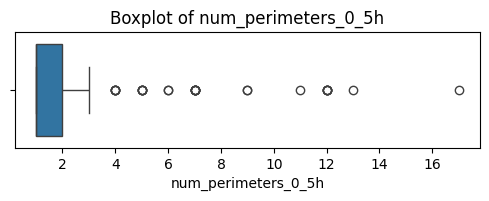

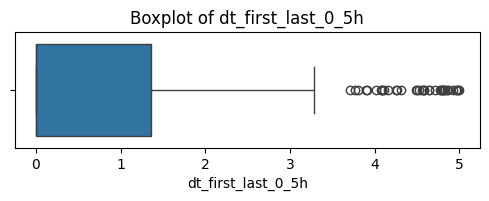

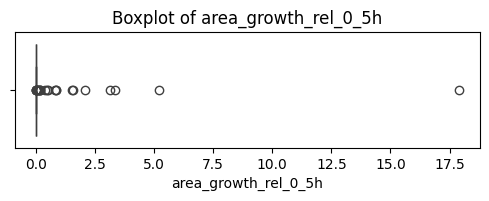

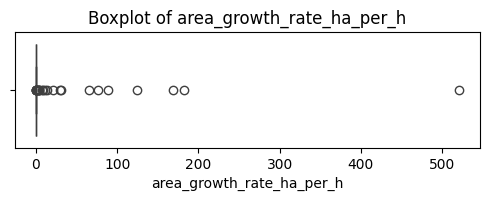

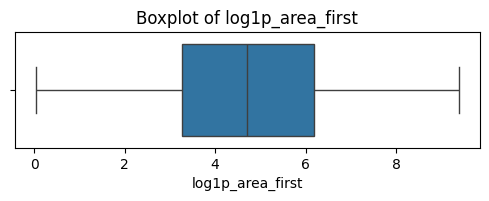

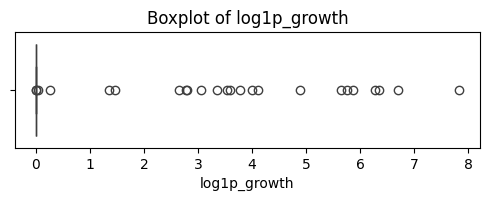

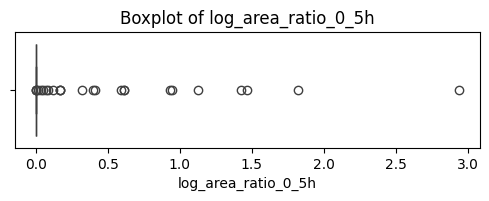

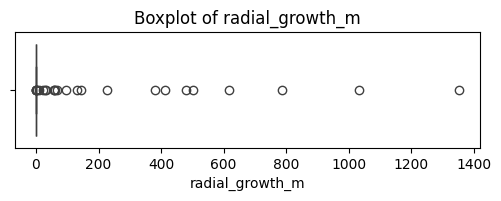

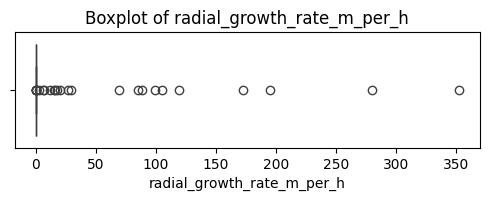

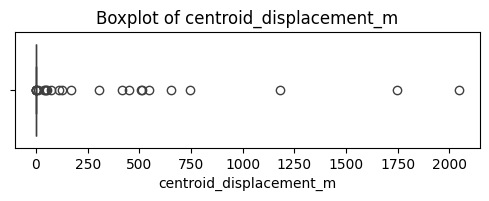

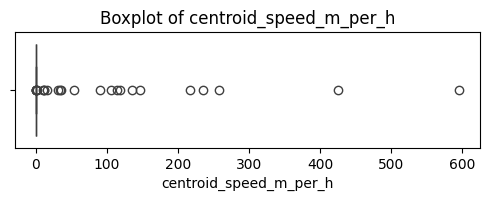

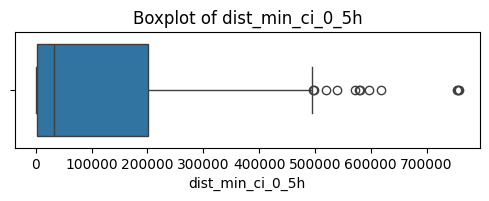

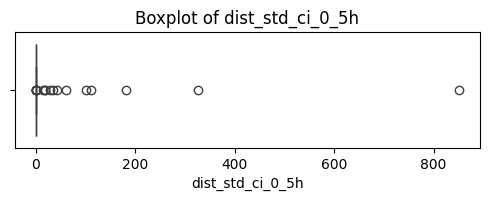

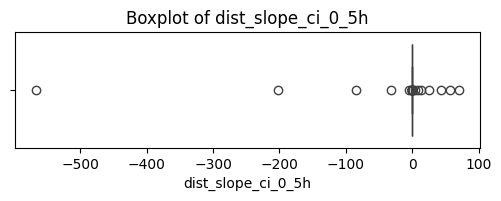

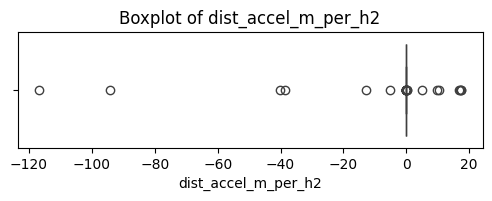

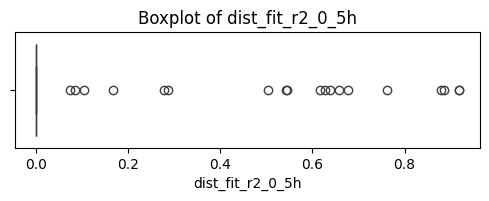

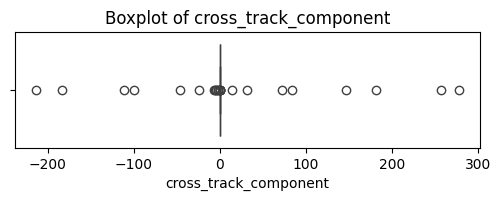

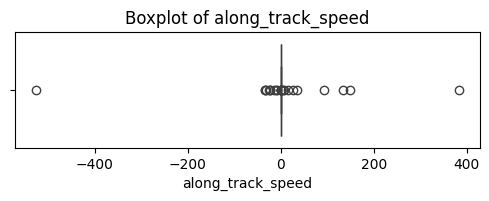

In [ ]:
skip_col_transformation = [
    # already -1 to 1 (already on a small scale)
    'spread_bearing_sin',
    'spread_bearing_cos',
    'alignment_cos',
    # already 0 or 1 (transformation would break meaning)
    'low_temporal_resolution_0_5h',
    'alignment_abs',
    # winsorization flattened it to 0
    'closing_speed_m_per_h',
    'projected_advance_m',
    'dist_change_ci_0_5h',
    # handling separately
    'event_start_hour',
    'event_start_dayofweek',
    'event_start_month',
    # target col (never transform)
    'hit_12h',
    'hit_24h',
    'hit_48h',
    'hit_72h'
]

cols = [col for col in df_encoded.columns if col not in skip_col_transformation]

for col in cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(data=df_encoded, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
cols_to_winsorize = [col for col in df_encoded.columns if col not in skip_col_transformation]
print(cols_to_winsorize)

['num_perimeters_0_5h', 'dt_first_last_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_slope_ci_0_5h', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'cross_track_component', 'along_track_speed']


Winsorization is a method to identify outliers and then replace those outliers with a high but acceptable value. Essentially, it handles outliers by capping extreme values at a specified percentile rather than removing them entirely.  

For features with outliers on both sides, winsorize 5% on both ends. For features with outliers on right side, winsorize 5% only on right side leaving left untouched.


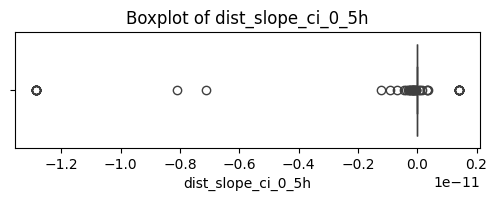

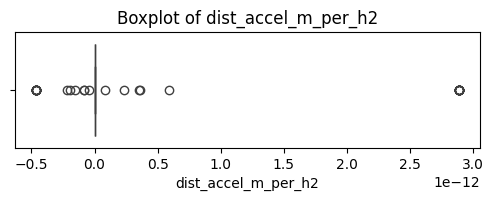

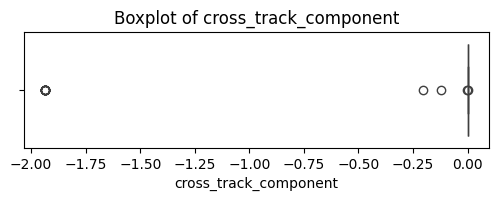

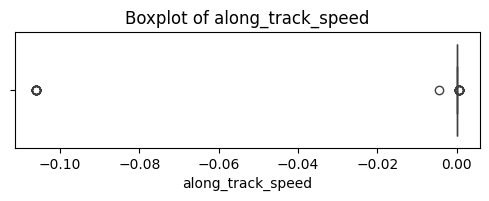

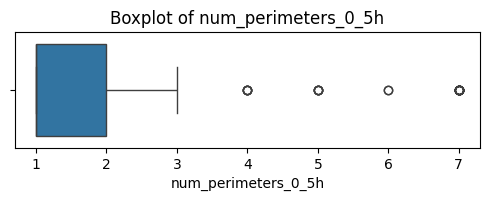

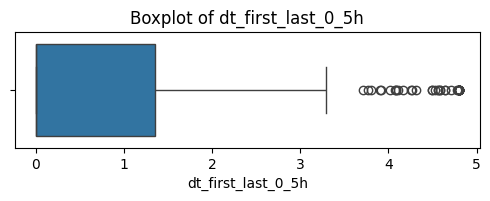

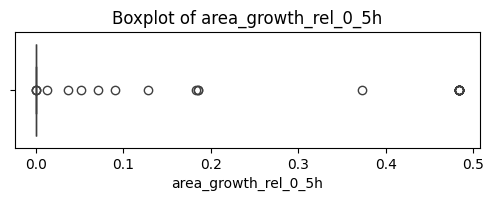

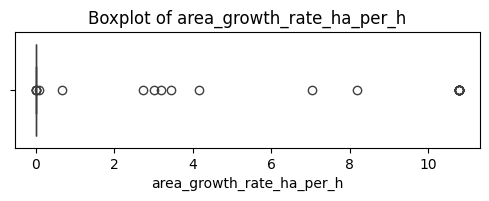

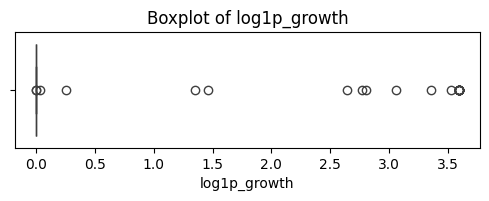

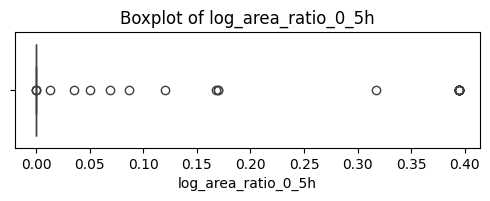

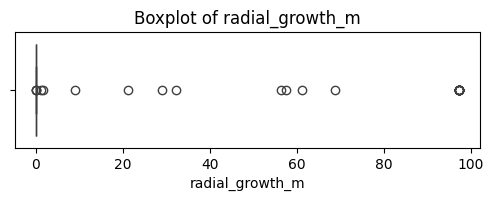

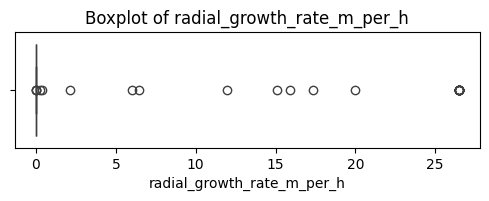

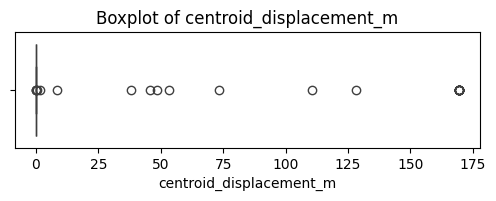

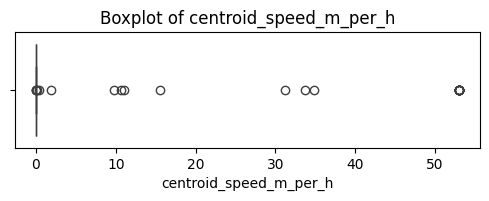

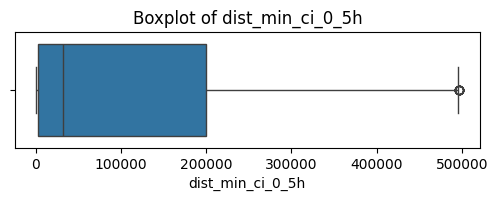

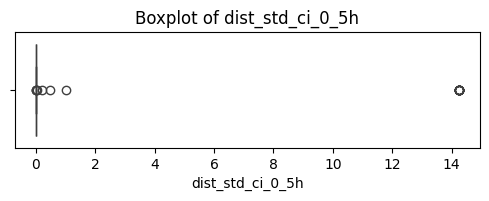

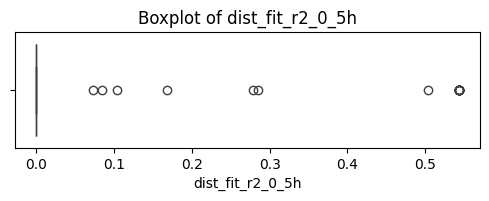

In [ ]:
# Make a copy of the dataframe
df_winsor = df_encoded.copy()

def winsorize_cols(df_input, cols_both, cols_right):
    df_output = df_input.copy()
    for col in cols_both:
        df_output[col] = stats.mstats.winsorize(df_input[col], limits=[0.05, 0.05])
    for col in cols_right:
        df_output[col] = stats.mstats.winsorize(df_input[col], limits=[0, 0.05])
    return df_output

cols_both = ["dist_slope_ci_0_5h",
             "dist_accel_m_per_h2", "cross_track_component", "along_track_speed"]

cols_right = ["num_perimeters_0_5h", "dt_first_last_0_5h", "area_growth_rel_0_5h", "area_growth_rate_ha_per_h",
              "log1p_growth", "log_area_ratio_0_5h", "radial_growth_m", "radial_growth_rate_m_per_h", "centroid_displacement_m",
             "centroid_speed_m_per_h", "dist_min_ci_0_5h", "dist_std_ci_0_5h", "dist_fit_r2_0_5h"]

# Winsorize the columns on the copy of the dataset by replacing the top and bottom 5% outlier values
df_winsor = winsorize_cols(df_winsor, cols_both, cols_right)

# Inspect the box plots again to see if the outliers have been handled
all_winsorized_cols = cols_both + cols_right

for col in all_winsorized_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(data=df_winsor, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

Scale the columns that need to be scaled.

In [ ]:
# select features to scale
cols_to_scale = [col for col in df_winsor.columns if col not in skip_col_transformation]

# initialize scaler
scaler = StandardScaler()
df_scaled = df_winsor.copy()

# scale the features
df_scaled[cols_to_scale] = scaler.fit_transform(df_winsor[cols_to_scale])

print(df_scaled[cols_to_scale].describe().round(2))

       num_perimeters_0_5h  dt_first_last_0_5h  area_growth_rel_0_5h  \
count               221.00              221.00                221.00   
mean                  0.00                0.00                 -0.00   
std                   1.00                1.00                  1.00   
min                  -0.48               -0.57                 -0.28   
25%                  -0.48               -0.57                 -0.28   
50%                  -0.48               -0.57                 -0.28   
75%                   0.09                0.22                 -0.28   
max                   2.93                2.22                  3.97   

       area_growth_rate_ha_per_h  log1p_area_first  log1p_growth  \
count                     221.00            221.00        221.00   
mean                       -0.00              0.00          0.00   
std                         1.00              1.00          1.00   
min                        -0.29             -2.24         -0.31   
25%        

In [ ]:
import numpy as np

Convert cyclical time features into sine and cosine components so the model understands their circular nature (23:00 is close to 00:00).

In [ ]:
df_scaled["hour_sin"] = np.sin(2 * np.pi * df_scaled["event_start_hour"] / 24)
df_scaled["hour_cos"] = np.cos(2 * np.pi * df_scaled["event_start_hour"] / 24)

df_scaled["day_sin"] = np.sin(2 * np.pi * df_scaled["event_start_dayofweek"] / 7)
df_scaled["day_cos"] = np.cos(2 * np.pi * df_scaled["event_start_dayofweek"] / 7)

df_scaled["month_sin"] = np.sin(2 * np.pi * (df_scaled["event_start_month"] - 1) / 12)
df_scaled["month_cos"] = np.cos(2 * np.pi * (df_scaled["event_start_month"] - 1) / 12)

In [ ]:
# drop original columns because they were replaced them with sin/cos components
df_scaled.drop(columns=["event_start_hour", "event_start_dayofweek", "event_start_month"], inplace=True)
print(df_scaled.columns.tolist())

['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'hit_12h', 'hit_24h', 'hit_48h', 'hit_72h', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos']


Create new features:  
- `time_to_reach`: `dist_min_ci_0_5h` / (`closing_speed_m_per_h` + 1)
    - fire closing in fast and distance to evacuation zone
- `threat_score`: `closing_speed_m_per_h` * `alignment_abs`
    - fire closing in fast and aligned directly towards an evacutation zone
- `growth_x_closing`: `area_growth_rate_ha_per_h` * `closing_speed_m_per_h`
    - fire closing in fast and growing at the same time

In [ ]:
df_final = df_scaled.copy()

# feature 1: estimated time to reach evac zone
df_final["time_to_reach"] = df_final["dist_min_ci_0_5h"] / (df_final["closing_speed_m_per_h"] + 1)

# feature 2: combines speed and direction into urgency measure
df_final["threat_score"] = df_final["closing_speed_m_per_h"] * (df_final["alignment_abs"])

# feature 3: insight for if fire is growing and closing in
df_final["growth_x_closing"] = df_final["area_growth_rate_ha_per_h"] * (df_final["closing_speed_m_per_h"])

print(df_final[["time_to_reach", "threat_score", "growth_x_closing"]].describe().round(2))

       time_to_reach  threat_score  growth_x_closing
count         221.00        221.00            221.00
mean            0.02          2.01              8.94
std             0.98         24.00            104.79
min            -0.81        -30.99           -201.69
25%            -0.74          0.00              0.00
50%            -0.43          0.00              0.00
75%             0.51          0.00              0.00
max             2.46        319.64           1389.64


Winsorize above 3 columns to remove any outliers.

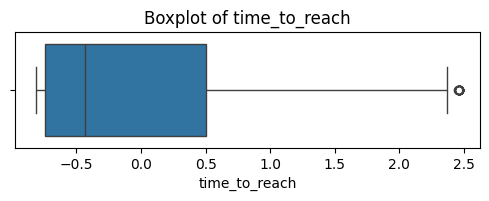

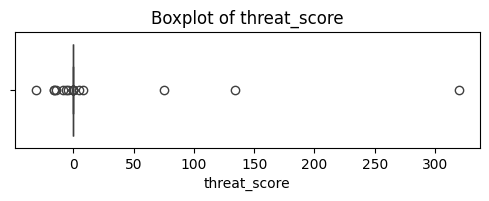

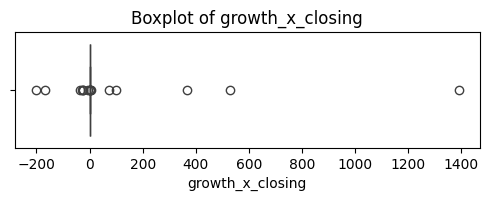

In [ ]:
custom_cols = [
    'time_to_reach',
    'threat_score',
    'growth_x_closing'
]

for col in custom_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(data=df_final, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

In [ ]:
df_final["threat_score"] = stats.mstats.winsorize(df_final["threat_score"], limits=[0.02, 0.02])
df_final["growth_x_closing"] = stats.mstats.winsorize(df_final["growth_x_closing"], limits=[0.02, 0.02])

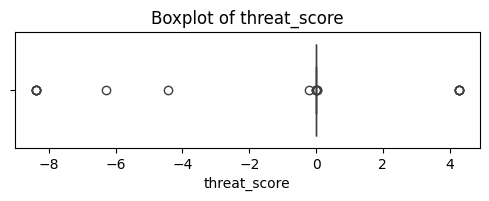

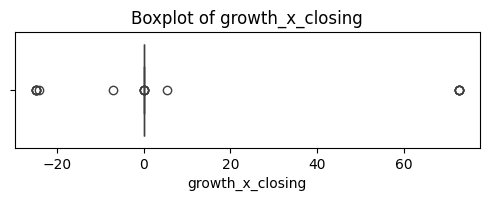

In [ ]:
winsorized_custom_cols = [
    'threat_score',
    'growth_x_closing'
]

for col in winsorized_custom_cols:
    plt.figure(figsize=(6, 1.5))
    sns.boxplot(data=df_final, x=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

Visualize correlations with new targets and interactions.  

Red = positively correlated (feature goes up, hit probability goes up)  
Blue = negatively correlated (feature goes up, hit probability goes down)  
White = no correlation

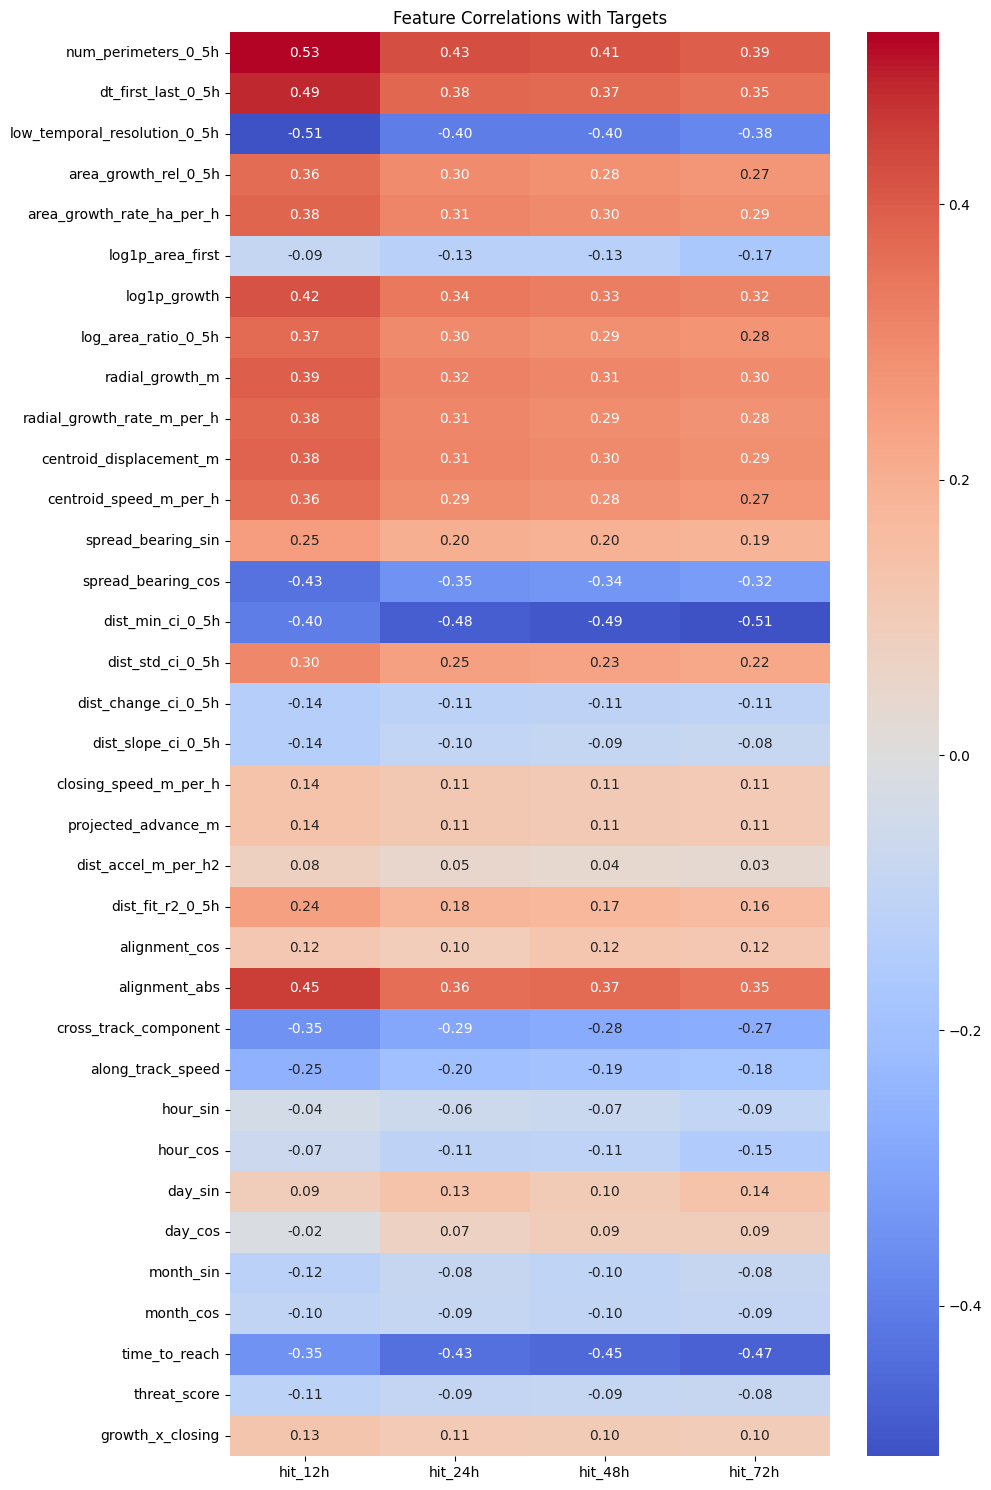

In [ ]:
# get correlations between all features and the 4 targets only
target_cols = ['hit_12h', 'hit_24h', 'hit_48h', 'hit_72h']
corr = df_final.corr()[target_cols].drop(target_cols)

# plot heatmap
plt.figure(figsize=(10, 15))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlations with Targets")
plt.tight_layout()
plt.show()

In [ ]:
df_final.head(10)

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,radial_growth_m,radial_growth_rate_m_per_h,...,hit_72h,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,time_to_reach,threat_score,growth_x_closing
0,0.658701,1.908894,0,0.034248,-0.022820,-0.140746,1.129974,0.092378,0.094393,0.037835,...,0,-0.965926,2.588190e-01,-0.433884,-0.900969,8.660254e-01,-0.500000,-0.813546,-0.005574,0.002328
1,0.090057,0.112996,0,-0.283580,-0.286058,-1.147787,-0.309516,-0.287616,-0.291530,-0.292255,...,1,0.866025,5.000000e-01,-0.433884,-0.900969,5.000000e-01,-0.866025,-0.751613,0.000000,-0.000000
2,1.227345,2.206156,0,-0.283580,-0.286058,-0.002861,-0.309516,-0.287616,-0.291530,-0.292255,...,1,-0.500000,8.660254e-01,-0.433884,-0.900969,-5.000000e-01,-0.866025,-0.749391,0.000000,-0.000000
3,-0.478587,-0.565799,1,-0.283580,-0.286058,-0.218649,-0.309516,-0.287616,-0.291530,-0.292255,...,0,-0.866025,5.000000e-01,-0.974928,-0.222521,-5.000000e-01,-0.866025,-0.353503,0.000000,-0.000000
4,0.090057,2.217827,0,-0.283580,-0.286058,-0.520649,-0.309516,-0.287616,-0.291530,-0.292255,...,0,-0.707107,7.071068e-01,-0.974928,-0.222521,1.224647e-16,-1.000000,-0.653535,0.000000,-0.000000
5,-0.478587,-0.565799,1,-0.283580,-0.286058,0.260351,-0.309516,-0.287616,-0.291530,-0.292255,...,0,0.000000,1.000000e+00,-0.974928,-0.222521,1.224647e-16,-1.000000,-0.541451,0.000000,-0.000000
6,-0.478587,-0.565799,1,-0.283580,-0.286058,0.051590,-0.309516,-0.287616,-0.291530,-0.292255,...,1,-0.707107,7.071068e-01,0.781831,0.623490,8.660254e-01,0.500000,-0.747712,0.000000,-0.000000
7,-0.478587,-0.565799,1,-0.283580,-0.286058,1.228235,-0.309516,-0.287616,-0.291530,-0.292255,...,0,-0.866025,-5.000000e-01,0.000000,1.000000,5.000000e-01,-0.866025,-0.718380,0.000000,-0.000000
8,0.090057,0.532404,0,-0.283580,-0.286058,-1.433333,-0.309516,-0.287616,-0.291530,-0.292255,...,0,-1.000000,-1.836970e-16,-0.974928,-0.222521,-5.000000e-01,-0.866025,-0.564053,0.000000,-0.000000
9,-0.478587,-0.565799,1,-0.283580,-0.286058,-1.373740,-0.309516,-0.287616,-0.291530,-0.292255,...,1,-0.965926,-2.588190e-01,0.974928,-0.222521,1.224647e-16,-1.000000,-0.757702,0.000000,-0.000000


In [ ]:
print(df_final.columns.tolist())

['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'hit_12h', 'hit_24h', 'hit_48h', 'hit_72h', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'time_to_reach', 'threat_score', 'growth_x_closing']


Use `df_final` for model development.

In [ ]:
#Drop target columns so model doesn't have the answers
X = df_final.drop(columns=target_cols)
y_12 = df_final['hit_12h']

In [ ]:
#Set up K-Fold
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
#Set up XGBoost on 12h
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, log_loss
xgb_12 = XGBClassifier(n_estimators=300,
                       max_depth = 5,
                       learning_rate=0.05,
                       random_state=42,
                       use_label_encoder=False,
                       eval_metric='logloss')

In [ ]:
#Develop ROC-AUC scores & Log Loss scores
auc_scores = []
logloss_scores = []
for train_index, val_index in skf.split(X, y_12):
  X_train, X_val = X.iloc[train_index], X.iloc[val_index]
  y_train, y_val = y_12.iloc[train_index], y_12.iloc[val_index]
  xgb_12.fit(X_train, y_train)

  probs = xgb_12.predict_proba(X_val)[:, 1]

  auc_scores.append(roc_auc_score(y_val, probs))
  logloss_scores.append(log_loss(y_val, probs))

print("Average ROC-AUC: ", np.mean(auc_scores))
print("Average Log-Loss: ", np.mean(logloss_scores))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Average ROC-AUC:  0.9694117647058824
Average Log-Loss:  0.2331196010680067


In [ ]:
#Train XGBoost on 12h
xgb_12.fit(X, y_12)

#Get feature importances (XGBoost calculates how important each feature was in making predictions)
importances = xgb_12.feature_importances_
df_feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by="importance", ascending=False)

print(df_feature_importance.head(10))

                feature  importance
14     dist_min_ci_0_5h    0.517796
1    dt_first_last_0_5h    0.151638
30            month_sin    0.061601
0   num_perimeters_0_5h    0.056639
5      log1p_area_first    0.039854
26             hour_sin    0.035328
31            month_cos    0.034379
28              day_sin    0.026407
32        time_to_reach    0.023033
22        alignment_cos    0.014216


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#Calibrate the 12h model (making sure model's confidence matches reality)
from sklearn.calibration import CalibratedClassifierCV
cal_xgb_12 = CalibratedClassifierCV(xgb_12, method='isotonic', cv=5)
cal_xgb_12.fit(X, y_12)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=300, n_jobs=None,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

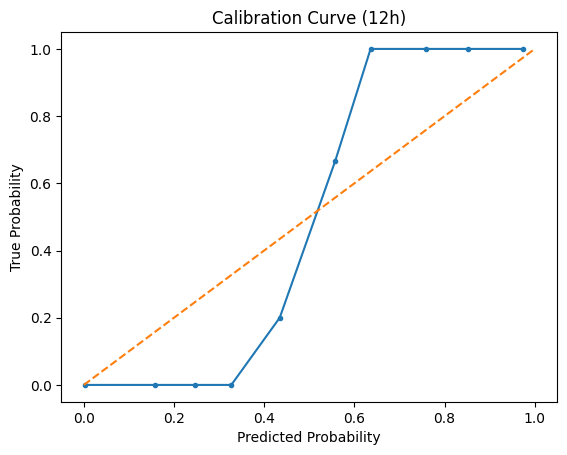

In [ ]:
#Plot calibration curve
from sklearn.calibration import calibration_curve

probs = cal_xgb_12.predict_proba(X)[:, 1]

prob_true, prob_pred = calibration_curve(y_12, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='.')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve (12h)')
plt.show()

In [ ]:
#Set up XGBoost on 24h
xgb_24 = XGBClassifier(n_estimators=300,
                       max_depth = 5,
                       learning_rate=0.05,
                       random_state=42,
                       use_label_encoder=False,
                       eval_metric='logloss'
                      )

In [ ]:
#Develop ROC-AUC scores & Log Loss scores
y_24 = df_final['hit_24h']
auc_scores = []
logloss_scores = []
for train_index, val_index in skf.split(X, y_24):
  X_train, X_val = X.iloc[train_index], X.iloc[val_index]
  y_train, y_val = y_24.iloc[train_index], y_24.iloc[val_index]
  xgb_24.fit(X_train, y_train)

  probs = xgb_24.predict_proba(X_val)[:, 1]

  auc_scores.append(roc_auc_score(y_val, probs))
  logloss_scores.append(log_loss(y_val, probs))

print("Average ROC-AUC: ", np.mean(auc_scores))
print("Average Log-Loss: ", np.mean(logloss_scores))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Average ROC-AUC:  0.9829792183622829
Average Log-Loss:  0.1239653076588575


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
#Train XGBoost on 24h
xgb_24.fit(X, y_24)

importances = xgb_24.feature_importances_
df_feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importances}).sort_values(by="importance", ascending=False)

print(df_feature_importance.head(10))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                feature  importance
14     dist_min_ci_0_5h    0.775634
0   num_perimeters_0_5h    0.037949
26             hour_sin    0.032937
27             hour_cos    0.028409
29              day_cos    0.027462
5      log1p_area_first    0.021464
28              day_sin    0.017631
22        alignment_cos    0.013875
23        alignment_abs    0.012524
30            month_sin    0.012405


In [ ]:
#Calibrate the 24h model
cal_xgb_24 = CalibratedClassifierCV(xgb_24, method='isotonic', cv=5)
cal_xgb_24.fit(X, y_12)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

CalibratedClassifierCV(cv=5,
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=None,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.05, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=5,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=300, n_jobs=None,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

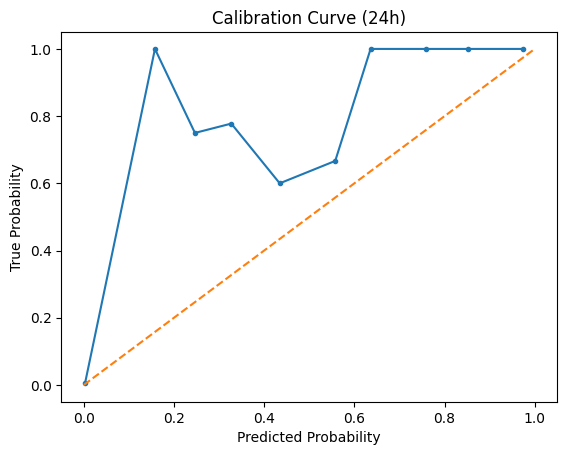

In [ ]:
#Plot Calibration Curve
probs = cal_xgb_24.predict_proba(X)[:, 1]

prob_true, prob_pred = calibration_curve(y_24, probs, n_bins=10)

plt.plot(prob_pred, prob_true, marker='.')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve (24h)')
plt.show()

In [ ]:
#Check how synchronized models are (if 12h predictions are less than 24h predictions)
#Enforce monotonicity so that there are no logic errors
pred_12 = xgb_12.predict_proba(X)[:, 1]
pred_24 = xgb_24.predict_proba(X)[:, 1]
pred_24_fixed = np.maximum(pred_24, pred_12)
np.mean(pred_12 > pred_24)
np.mean(pred_12 > pred_24_fixed)

np.float64(0.0)

In [ ]:
y_48 = df_final["hit_48h"].astype(int)
y_72 = df_final["hit_72h"].astype(int)
print("48h positive rate:", round(y_48.mean(), 3))
print("72h positive rate:", round(y_72.mean(), 3))

48h positive rate: 0.299
72h positive rate: 0.312


In [ ]:
xgb_48 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

auc_scores_48 = []
logloss_scores_48 = []
oof_48_xgb = np.zeros(len(y_48))

for train_idx, val_idx in skf.split(X, y_48):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y_48.iloc[train_idx], y_48.iloc[val_idx]

    xgb_48.fit(X_train, y_train)
    probs = xgb_48.predict_proba(X_val)[:, 1]

    oof_48_xgb[val_idx] = probs
    auc_scores_48.append(roc_auc_score(y_val, probs))
    logloss_scores_48.append(log_loss(y_val, probs))

print("XGB 48h Average ROC-AUC:", np.mean(auc_scores_48))
print("XGB 48h Average Log-Loss:", np.mean(logloss_scores_48))

XGB 48h Average ROC-AUC: 0.996029776674938
XGB 48h Average Log-Loss: 0.05813659404717129


In [ ]:
xgb_72 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

auc_scores_72, logloss_scores_72 = [], []
oof_72_xgb = np.zeros(len(y_72))

for train_idx, val_idx in skf.split(X, y_72):
  X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
  y_train, y_val = y_72.iloc[train_idx], y_72.iloc[val_idx]

  xgb_72.fit(X_train, y_train)
  probs = xgb_72.predict_proba(X_val)[:, 1]

  oof_72_xgb[val_idx] = probs
  auc_scores_72.append(roc_auc_score(y_val, probs))
  logloss_scores_72.append(log_loss(y_val, probs))

print("XGB 72h Average ROC-AUC:", np.mean(auc_scores_72))
print("XGB 72h Average Log-Loss:", np.mean(logloss_scores_72))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:35:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGB 72h Average ROC-AUC: 0.9935483870967742
XGB 72h Average Log-Loss: 0.04796171436703599


In [ ]:
print("X_shape:", X.shape)
targets_in_X = [c for c in ['hit_12h', 'hit_24h', 'hit_48h', 'hit_72h'] if c in X.columns]
print("Target columns present in X (should be []):", targets_in_X)
X.head(2)

X_shape: (221, 35)
Target columns present in X (should be []): []


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,radial_growth_m,radial_growth_rate_m_per_h,...,along_track_speed,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,time_to_reach,threat_score,growth_x_closing
0,0.658701,1.908894,0,0.034248,-0.022820,-0.140746,1.129974,0.092378,0.094393,0.037835,...,-4.172948,-0.965926,0.258819,-0.433884,-0.900969,0.866025,-0.500000,-0.813546,-0.005574,0.002328
1,0.090057,0.112996,0,-0.283580,-0.286058,-1.147787,-0.309516,-0.287616,-0.291530,-0.292255,...,0.239178,0.866025,0.500000,-0.433884,-0.900969,0.500000,-0.866025,-0.751613,0.000000,-0.000000


In [ ]:
try:
    from lightgbm import LGBMClassifier
    use_lgbm = True
except:
    use_lgbm = False

if use_lgbm:
    lgb_48 = LGBMClassifier(n_estimators=2000, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1)
    auc48_lgb, ll48_lgb = [], []
    for tr, va in skf.split(X, y_48):
        lgb_48.fit(X.iloc[tr], y_48.iloc[tr])
        p = lgb_48.predict_proba(X.iloc[va])[:,1]
        auc48_lgb.append(roc_auc_score(y_48.iloc[va], p))
        ll48_lgb.append(log_loss(y_48.iloc[va], p))
    print("LGBM 48h AUC:", np.mean(auc48_lgb), "LogLoss:", np.mean(ll48_lgb))

    lgb_72 = LGBMClassifier(n_estimators=2000, learning_rate=0.03, num_leaves=31, random_state=42)
    auc72_lgb, ll72_lgb = [], []
    for tr, va in skf.split(X, y_72):
        lgb_72.fit(X.iloc[tr], y_72.iloc[tr])
        p = lgb_72.predict_proba(X.iloc[va])[:,1]
        auc72_lgb.append(roc_auc_score(y_72.iloc[va], p))
        ll72_lgb.append(log_loss(y_72.iloc[va], p))
    print("LGBM 72h AUC:", np.mean(auc72_lgb), "LogLoss:", np.mean(ll72_lgb))

LGBM 48h AUC: 0.996029776674938 LogLoss: 0.14099450705350153
LGBM 72h AUC: 0.9990074441687344 LogLoss: 0.09712113474895553


In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

base48 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

base72 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric="logloss"
)

cal48 = CalibratedClassifierCV(base48, method="isotonic", cv=5)
cal72 = CalibratedClassifierCV(base72, method="isotonic", cv=5)

cal48.fit(X, y_48)
cal72.fit(X, y_72)

p48_cal = cal48.predict_proba(X)[:,1]
p72_cal = cal72.predict_proba(X)[:,1]

print("Calibrated 48h LogLoss:", log_loss(y_48, p48_cal))
print("Calibrated 72h LogLoss:", log_loss(y_72, p72_cal))

Calibrated 48h LogLoss: 0.014604405127571315
Calibrated 72h LogLoss: 0.008346444743183183


In [ ]:
p12 = cal_xgb_12.predict_proba(X)[:,1]
p24 = cal_xgb_24.predict_proba(X)[:,1]

p48 = p48_cal
p72 = p72_cal

p24_m = np.maximum(p24, p12)
p48_m = np.maximum(p48, p24_m)
p72_m = np.maximum(p72, p48_m)

print("Violations(there shouldn't be any)")
print("p12 > p24:", np.sum(p12 > p24_m))
print("p24 > p48:", np.sum(p24_m > p48_m))
print("p48 > p72:", np.sum(p48_m > p72_m))

Violations(there shouldn't be any)
p12 > p24: 0
p24 > p48: 0
p48 > p72: 0


In [ ]:
base48.fit(X, y_48)
base72.fit(X, y_72)

imp48 = pd.Series(base48.feature_importances_, index=X.columns).sort_values(ascending=False)
imp72 = pd.Series(base72.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 drivers for 48h:")
print(imp48.head(10))

print("\nBottom 10 (possible discard candidates) for 48h:")
print(imp48.tail(10))

print("\nTop 10 drivers for 72h:")
print(imp72.head(10))

print("\nBottom 10 (possible discard candidates) for 72h:")
print(imp72.tail(10))

Top 10 drivers for 48h:
dist_min_ci_0_5h       0.855669
num_perimeters_0_5h    0.045096
hour_cos               0.026948
log1p_area_first       0.023206
hour_sin               0.014921
day_sin                0.012230
month_cos              0.008230
month_sin              0.006501
time_to_reach          0.004794
day_cos                0.002405
dtype: float32

Bottom 10 (possible discard candidates) for 48h:
centroid_speed_m_per_h    0.0
projected_advance_m       0.0
along_track_speed         0.0
cross_track_component     0.0
alignment_abs             0.0
alignment_cos             0.0
dist_accel_m_per_h2       0.0
dist_fit_r2_0_5h          0.0
threat_score              0.0
growth_x_closing          0.0
dtype: float32

Top 10 drivers for 72h:
dist_min_ci_0_5h                1.0
dt_first_last_0_5h              0.0
num_perimeters_0_5h             0.0
low_temporal_resolution_0_5h    0.0
area_growth_rel_0_5h            0.0
log1p_area_first                0.0
area_growth_rate_ha_per_h       0.0

48h
features that drive predictions:dist_min_ci_0_5h, num_perimeters_0_5h, log1p_area_first
features that may be discarded:centroid_speed_m_per_h, projected_advance_m, along_track_speed, cross_track_component, alignment_abs, alignment_cos, dist_accel_m_per_h2, dist_fit_r2_0_5h, threat_score, growth_x_closing

72h
features that drive predictions:dist_min_ci_0_5h
features that may be discarded:pretty much everything else